In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# 1) Load the given dataset

In [2]:
cd C:\Users\rjban\Desktop\ml\ML Projects

C:\Users\rjban\Desktop\ml\ML Projects


In [3]:
df=pd.read_csv("ML Project - Decision Tree Airline Customer Satisfaction.txt")

In [4]:
df.shape

(10000, 26)

In [5]:
df.head(2)

,Unnamed: 0.1,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied


# 2) Print all the column names

In [7]:
df.columns.tolist()

['Unnamed: 0.1',
 'Unnamed: 0',
 'id',
 'Gender',
 'Customer Type',
 'Age',
 'Type of Travel',
 'Class',
 'Flight Distance',
 'Inflight wifi service',
 'Departure/Arrival time convenient',
 'Ease of Online booking',
 'Gate location',
 'Food and drink',
 'Online boarding',
 'Seat comfort',
 'Inflight entertainment',
 'On-board service',
 'Leg room service',
 'Baggage handling',
 'Checkin service',
 'Inflight service',
 'Cleanliness',
 'Departure Delay in Minutes',
 'Arrival Delay in Minutes',
 'satisfaction']

# 3) Describe the data

In [8]:
df.describe()

,Unnamed: 0.1,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,9974.000000
mean,4999.50000,4999.50000,64950.978500,39.303700,1198.823800,2.731500,3.038900,2.753600,2.96890,3.208800,...,3.411300,3.335500,3.366000,3.346500,3.619900,3.285600,3.627400,3.268200,14.785400,15.242130
std,2886.89568,2886.89568,37420.905082,15.116478,1001.774138,1.328226,1.528077,1.403241,1.28425,1.339769,...,1.326012,1.340567,1.288336,1.311415,1.190028,1.269013,1.181401,1.321077,38.217509,38.810195
min,0.00000,0.00000,8.000000,7.000000,31.000000,0.000000,0.000000,0.000000,1.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2499.75000,2499.75000,32330.500000,27.000000,413.000000,2.000000,2.000000,2.000000,2.00000,2.000000,...,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,0.000000,0.000000
50%,4999.50000,4999.50000,64941.000000,40.000000,852.500000,3.000000,3.000000,3.000000,3.00000,3.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,7499.25000,7499.25000,97579.750000,51.000000,1747.000000,4.000000,4.000000,4.000000,4.00000,4.000000,...,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,13.000000,13.000000
max,9999.00000,9999.00000,129863.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.00000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1305.000000,1280.000000


# 4) Drop the column ‘Unnamed: 0’

In [9]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'id', 'Gender', 'Customer Type', 'Age',
       'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

In [ ]:
df = df.drop(columns=["Unnamed: 0"])

# 5) Replace all the " " in column names with "_"

In [12]:
df.columns = df.columns.str.replace(" ", "_")

In [13]:
df.columns.tolist()

['Unnamed:_0.1',
 'id',
 'Gender',
 'Customer_Type',
 'Age',
 'Type_of_Travel',
 'Class',
 'Flight_Distance',
 'Inflight_wifi_service',
 'Departure/Arrival_time_convenient',
 'Ease_of_Online_booking',
 'Gate_location',
 'Food_and_drink',
 'Online_boarding',
 'Seat_comfort',
 'Inflight_entertainment',
 'On-board_service',
 'Leg_room_service',
 'Baggage_handling',
 'Checkin_service',
 'Inflight_service',
 'Cleanliness',
 'Departure_Delay_in_Minutes',
 'Arrival_Delay_in_Minutes',
 'satisfaction']

# 6) Give label to a satisfaction column value without using any encoding method

In [19]:
df["satisfaction"] = df["satisfaction"].apply(lambda x: 1 if x == "satisfied" else 0)

In [20]:
df["satisfaction"].value_counts()

satisfaction
0    10000
Name: count, dtype: int64

# 7) Plot the number of satisfied customers and the number of unsatisfied customers

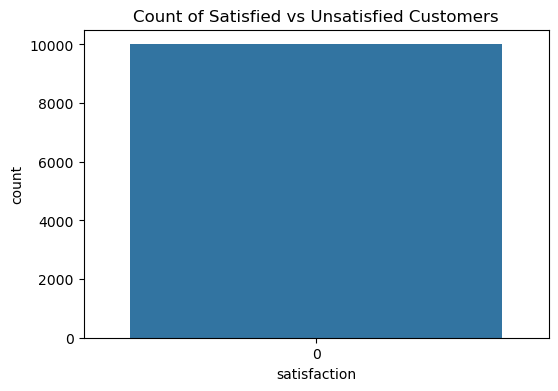

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x="satisfaction", data=df)
plt.title("Count of Satisfied vs Unsatisfied Customers")
plt.show()

# 8) Find the mean value of satisfaction of male and female customers

In [22]:
df.groupby("Gender")["satisfaction"].mean()

Gender
Female    0.0
Male      0.0
Name: satisfaction, dtype: float64

# 9) Find the mean value of satisfaction of customers with respect to Age

In [23]:
df.groupby("Age")["satisfaction"].mean().head(10)

Age
7     0.0
8     0.0
9     0.0
10    0.0
11    0.0
12    0.0
13    0.0
14    0.0
15    0.0
16    0.0
Name: satisfaction, dtype: float64

# 10) Find the mean value of satisfaction of customers with respect to Food_and_drink

In [24]:
df.groupby("Food_and_drink")["satisfaction"].mean()

Food_and_drink
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
Name: satisfaction, dtype: float64

# 11) Display a boxplot for Flight_Distance

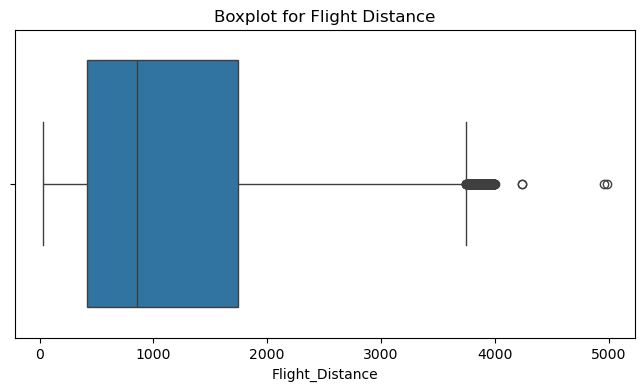

In [25]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Flight_Distance"])
plt.title("Boxplot for Flight Distance")
plt.show()

# 12) Display a boxplot for Checkin_service

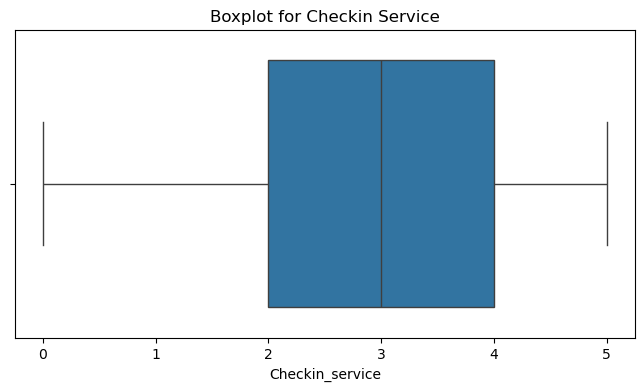

In [26]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Checkin_service"])
plt.title("Boxplot for Checkin Service")
plt.show()

# 13) Find all the Null values

In [27]:
df.isnull().sum()

Unnamed:_0.1                          0
id                                    0
Gender                                0
Customer_Type                         0
Age                                   0
Type_of_Travel                        0
Class                                 0
Flight_Distance                       0
Inflight_wifi_service                 0
Departure/Arrival_time_convenient     0
Ease_of_Online_booking                0
Gate_location                         0
Food_and_drink                        0
Online_boarding                       0
Seat_comfort                          0
Inflight_entertainment                0
On-board_service                      0
Leg_room_service                      0
Baggage_handling                      0
Checkin_service                       0
Inflight_service                      0
Cleanliness                           0
Departure_Delay_in_Minutes            0
Arrival_Delay_in_Minutes             26
satisfaction                          0


# 14) Drop all the na values

In [28]:
df = df.dropna()

# 15) Find the unique values in Flight_Distance

In [30]:
df["Flight_Distance"].nunique()

2430

# Part-2: Working with Models
# 1) Perform encoding in columns Gender, Customer_Type, Type_of_Travel, and Class

In [31]:
le = LabelEncoder()
encode_cols = ["Gender", "Customer_Type", "Type_of_Travel", "Class"]
for col in encode_cols:
    df[col] = le.fit_transform(df[col])

C:\Users\rjban\AppData\Local\Temp\ipykernel_7812\1386821319.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = le.fit_transform(df[col])
C:\Users\rjban\AppData\Local\Temp\ipykernel_7812\1386821319.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = le.fit_transform(df[col])
C:\Users\rjban\AppData\Local\Temp\ipykernel_7812\1386821319.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

S

# 2) Drop the column id and unnamed:_0.1 

In [32]:
cols_to_drop = ["Unnamed:_0.1"]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# 3) Create the features (X) and target Data (y)

In [33]:
x = df.drop("satisfaction", axis=1)
y = df["satisfaction"]

# 4) Perform scaling on features data

In [35]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# 5) Split the data in training and testing sets

In [36]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

# 6) Fit the decision tree model with various parameters

In [37]:
dt_model = DecisionTreeClassifier(criterion="entropy", max_depth=10, random_state=42)
dt_model.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=42)

# 7) Create a function to display evaluation metrics

In [43]:
def display_metrics(yt, yp):
    print("Decision Tree Model Evaluation")
    print(f"Accuracy:        {accuracy_score(yt, yp):.4f}")
    print(f"Precision:       {precision_score(yt, yp):.4f}")
    print(f"Recall:          {recall_score(yt, yp):.4f}")
    print(f"F1 Score:        {f1_score(yt, yp):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(yt, yp))
    print("\nClassification Report:")
    print(classification_report(yt, yp))

In [44]:
yp = dt_model.predict(x_test)
display_metrics(y_test, yp)

Decision Tree Model Evaluation
Accuracy:        1.0000
Precision:       0.0000
Recall:          0.0000
F1 Score:        0.0000

Confusion Matrix:
[[1995]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1995

    accuracy                           1.00      1995
   macro avg       1.00      1.00      1.00      1995
weighted avg       1.00      1.00      1.00      1995



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_class